## Predicting Online Purchase Behavior

Can we predict whether a user will complete a purchase based on their browsing behavior?

In this project, we build a machine learning model to classify whether an online shopping session results in a purchase (**binary classification**).

**Target Variable:** `PurchaseCompleted`

---

## Objective of EDA

Before building models, we perform Exploratory Data Analysis (EDA) to:

- Understand the dataset structure and feature distributions  
- Identify data quality issues and perform cleaning  
- Explore relationships between features and the target variable  
- Extract insights that can guide feature engineering and model selection 

## 1. Data Overview

Let’s take a quick look at the dataset to understand its structure and features.

We will:
- Inspect the dataset shape and data types  
- Explore the available features  
- Identify any potential data quality issues (e.g. missing or inconsistent values)

## Import Packages 

In [2]:
## import pacakages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 as sql
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Setup Connection and Load Data

We start by connecting to the SQLite database and loading the `online_shopping` table into a pandas DataFrame.

In [3]:
## setup connection and load the .db file
database = "online_shoppingg.db"
connection = sql.connect(database)
cursor = connection.cursor()
df = pd.read_sql_query("SELECT * FROM online_shopping", connection)

## Inspect Dataset Structure

In [4]:
## Show struture and sample values of what the dataset looks like
df.head()

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
0,Returning_Visitor,0.0,0.20,0.0,1.0,1,0.20,0.000000,0
1,Returning_Visitor,0.0,0.10,0.0,2.0,1,0.00,64.000000,0
2,Returning_Visitor,NaN,0.20,0.0,3.0,-9,0.20,0.000000,0
3,Returning_Visitor,0.0,0.14,0.0,4.0,2,0.05,2.666667,0
4,Returning_Visitor,0.0,NaN,NaN,4.0,1,0.02,627.500000,0


In [5]:
## Check for dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerType         12330 non-null  str    
 1   SpecialDayProximity  11714 non-null  float64
 2   ExitRate             11714 non-null  float64
 3   PageValue            11714 non-null  float64
 4   TrafficSource        11714 non-null  float64
 5   GeographicRegion     12330 non-null  int64  
 6   BounceRate           12330 non-null  float64
 7   ProductPageTime      11714 non-null  float64
 8   PurchaseCompleted    12330 non-null  int64  
dtypes: float64(6), int64(2), str(1)
memory usage: 867.1 KB


In [6]:
## Check for overall missing values
df.isnull().sum()

CustomerType             0
SpecialDayProximity    616
ExitRate               616
PageValue              616
TrafficSource          616
GeographicRegion         0
BounceRate               0
ProductPageTime        616
PurchaseCompleted        0
dtype: int64

### Observations on Missing Values
- 5 features contain 616 missing entries (~5% of the dataset).  
- These missing values will be addressed later in the **Data Cleaning** section.

##  Summary Statistics

In [7]:
## Check for the overall mean, std, percentile to better understand the dataset
df.describe()

,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
count,11714.000000,11714.000000,11714.000000,11714.000000,12330.000000,12330.000000,11714.000000,12330.000000
mean,0.060833,0.043058,5.906249,4.059501,2.840308,0.020024,1198.698632,0.154745
std,0.197459,0.048506,18.682351,4.015758,2.757959,0.049423,1928.871645,0.361676
min,0.000000,0.000000,0.000000,1.000000,-9.000000,-0.200000,-52.500000,0.000000
25%,0.000000,0.014286,0.000000,2.000000,1.000000,0.000000,184.270833,0.000000
50%,0.000000,0.025286,0.000000,2.000000,2.000000,0.001961,602.958333,0.000000
75%,0.000000,0.050000,0.000000,4.000000,4.000000,0.015625,1465.955181,0.000000
max,1.000000,0.200000,361.763742,20.000000,9.000000,0.200000,63973.522230,1.000000


In [8]:
df.nunique()

CustomerType              8
SpecialDayProximity       6
ExitRate               4589
PageValue              2581
TrafficSource            20
GeographicRegion         18
BounceRate             2011
ProductPageTime        9128
PurchaseCompleted         2
dtype: int64

## Categorical Feature Observations

In [9]:
## Obseve the IDs in CustomerType
df['CustomerType'].value_counts()

CustomerType
Returning_Visitor    10022
New_Visitor           1605
                       166
nan                    153
None                   153
Unknown                144
Other                   83
returning_Visitor        4
Name: count, dtype: int64

In [10]:
##Observe the IDs in GeographicRegion
df['GeographicRegion'].value_counts()

GeographicRegion
 1    4536
 3    2283
 4    1123
 2    1078
 6     772
 7     724
 9     488
 8     413
 5     297
-1     244
-3     120
-4      59
-2      58
-7      37
-6      33
-9      23
-8      21
-5      21
Name: count, dtype: int64

## Key Observations

1. **Missing Values**  
   5 features contain 616 missing entries (~5%). These will be handled later during **Data Cleaning**.

2. **Geographic Region**  
   Some values (like -9) are invalid and will be imputed or assigned to an "Unknown" category.

3. **Bounce Rate & Product Page Time**  
   Negative values are present, which are impossible in context. They will be corrected or treated in **Data Cleaning**.

4. **Customer Type**  
   There are 8 unique categories instead of the expected 3. Some categories may need grouping or relabeling during preprocessing.

> These observations highlight data quality issues that will be addressed in the **Data Cleaning & Preprocessing** section before deeper analysis.

# 2.0 Data Cleaning

In this section, we address the data quality issues highlighted in Section 1.0.  
We will systematically handle out-of-place values, missing entries, and categorical inconsistencies before proceeding to feature engineering and modeling.

## Out-of-Place Variables

BounceRate and ProductPageTime contain impossible negative values.  
These variables can skew mean/median calculations and affect imputation for missing values later.  

**Strategy**: Replace negative values with `NaN` to preserve valid rows and allow consistent handling of missing data.

In [11]:
## find out how many rows are there that still have missing values. 

# negative rows for both variables
invalid_bounce = df[df['BounceRate'] < 0]
invalid_page = df[df['ProductPageTime'] < 0]

# Count how many of these rows have any other missing values
bounce_missing_count = invalid_bounce.isnull().sum(axis=1).gt(0).sum()
page_missing_count = invalid_page.isnull().sum(axis=1).gt(0).sum()

print(f"BounceRate negative rows with other missing values: {bounce_missing_count} out of {len(invalid_bounce)}")
print(f"ProductPageTime negative rows with other missing values: {page_missing_count} out of {len(invalid_page)}")

BounceRate negative rows with other missing values: 92 out of 348
ProductPageTime negative rows with other missing values: 2 out of 4


In [12]:
## We will preserve these values as nan, since they are a small data set 

df.loc[df['BounceRate'] < 0, 'BounceRate'] = pd.NA
df.loc[df['ProductPageTime'] < 0, 'ProductPageTime'] = pd.NA

### Observation and Conclusion

**Observation**:  
- `BounceRate` and `ProductPageTime` had negative values, which are not possible in this context.

**Action Taken**:  
- Replaced negative values with `NaN` to maintain consistency and allow downstream imputation.

**Reasoning**:  
- Preserving the rest of the row ensures we do not lose valid information in other features.

## Missing Values

In this section, we investigate and handle missing values in the dataset. Missing data can impact model performance if not treated properly, so we first explore where and how the missing values occur.

In [13]:
# Show updated missing values after handling out-of-place variables
df.isnull().sum()

CustomerType             0
SpecialDayProximity    616
ExitRate               616
PageValue              616
TrafficSource          616
GeographicRegion         0
BounceRate             348
ProductPageTime        620
PurchaseCompleted        0
dtype: int64

### Visualize Missing Values

We create a heatmap to visualize the missing values in the dataset. This helps us see if there are any patterns or clusters of missing data.

Text(0.5, 1.0, 'Missing Values')

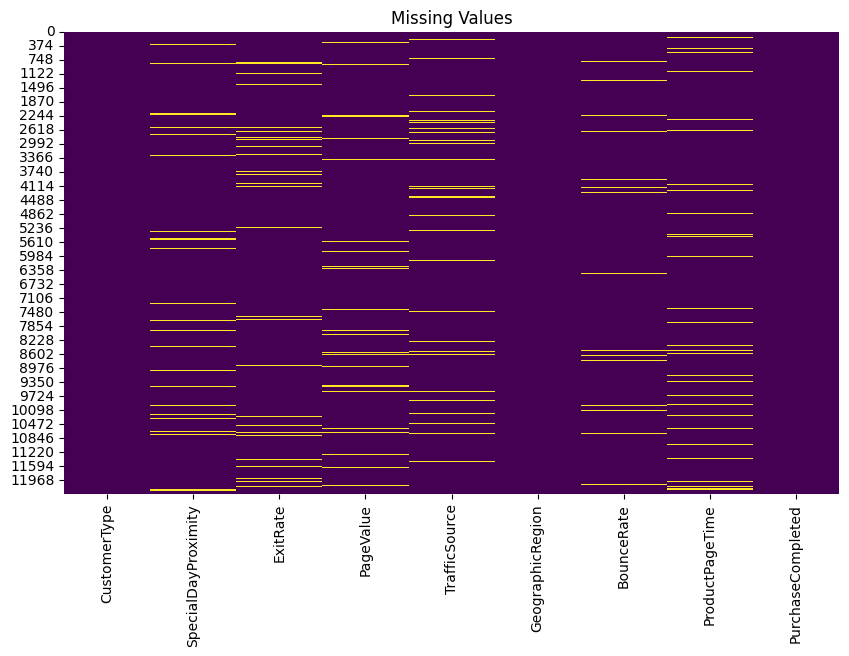

In [14]:
## plot a heatmap to visualize the missing values

plt.figure(figsize = (10, 6))
sns.heatmap(df.isnull(), cbar = False, cmap = 'viridis')
plt.title('Missing Values')

### Count Missing Values Per Row

We check how many rows have missing values and how many features are missing in each row. Most rows have a small number of missing values, but a few rows have multiple missing entries.

In [15]:
## Check number of rows with missing values 
missing_per_row = df.isnull().sum(axis=1)
missing_per_row.value_counts()

0    9294
1    2674
2     329
3      32
4       1
Name: count, dtype: int64

### Impact of Missing Values on Target Variable

Next, we investigate whether missing values are related to our target variable `PurchaseCompleted`. If the purchase rate differs significantly between missing and non-missing rows, we may need to handle these rows carefully.

In [16]:
missing_cols = df.columns[df.isnull().any()]

rows = []

for col in missing_cols:
    rates = df.groupby(df[col].isnull())['PurchaseCompleted'].mean()
    rows.append({
        'Feature': col,
        'Purchase Rate (Non-Missing values)': rates.get(False, 0),
        'Purchase Rate (Missing values)': rates.get(True, 0)
    })

missing_vs_target = pd.DataFrame(rows)
missing_vs_target

,Feature,Purchase Rate (Non-Missing values),Purchase Rate (Missing values)
0,SpecialDayProximity,0.155370,0.142857
1,ExitRate,0.155540,0.139610
2,PageValue,0.155199,0.146104
3,TrafficSource,0.154687,0.155844
4,BounceRate,0.154982,0.146552
5,ProductPageTime,0.154483,0.159677


### Observation

- The difference in purchase rates between missing and non-missing values is relatively small.  
- This suggests that missing values are likely **missing at random**, and dropping these rows may unnecessarily reduce our dataset size.

### Imputation Strategy

To preserve the dataset:

- **Numerical features**: Impute using the **median** to reduce the influence of outliers.  
- **Categorical features**: Replace missing values with `"Unknown"` to retain all rows without making assumptions.

In [17]:
## Impute the variables with missing values, with median 

# List of numerical columns to impute
num_cols = ['SpecialDayProximity', 'ExitRate', 'PageValue', 'BounceRate', 'ProductPageTime']

# Median imputation for numerical columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
    
# replace the missing values in trafficsource to unknown
df['TrafficSource'] = df['TrafficSource'].fillna('Unknown')

## Ensure that there are no more missing values 
df.isnull().sum()

CustomerType           0
SpecialDayProximity    0
ExitRate               0
PageValue              0
TrafficSource          0
GeographicRegion       0
BounceRate             0
ProductPageTime        0
PurchaseCompleted      0
dtype: int64

### Conclusion

- Missing values were scattered randomly across the dataset.  
- Dropping rows with missing values would remove ~24% of the dataset, which could negatively affect model performance.  
- By imputing numerical values with the median and replacing categorical missing values with `"Unknown"`, we preserve the majority of our data while maintaining data integrity for modeling.

## Geographic Region
Here we would handle geographic region, 

In [18]:
## Look at the number of values per category here
df['GeographicRegion'].value_counts()

GeographicRegion
 1    4536
 3    2283
 4    1123
 2    1078
 6     772
 7     724
 9     488
 8     413
 5     297
-1     244
-3     120
-4      59
-2      58
-7      37
-6      33
-9      23
-8      21
-5      21
Name: count, dtype: int64

### Handling Invalid Values

From the distribution above, we observe that some region values are negative, which do not correspond to valid geographic regions.

To address this, we group these invalid values into a single `"Unknown"` category.

In [19]:
## Label all the negative regions with unknown
# Replace negative or invalid region codes with 'Unknown'
df['GeographicRegion'] = df['GeographicRegion'].apply(lambda x: 'Unknown' if x < 1 else x)

In [20]:
## Verify that the invalid regions are grouped together
df['GeographicRegion'].value_counts()

GeographicRegion
1          4536
3          2283
4          1123
2          1078
6           772
7           724
Unknown     616
9           488
8           413
5           297
Name: count, dtype: int64

### Observation

- The `GeographicRegion` feature contained invalid negative values (e.g. -1 to -9).  
- These values do not represent real regions and are likely due to data entry or encoding issues.

### Conclusion

- Invalid region values were replaced with `"Unknown"` to avoid incorrect assumptions.  
- This allows the model to treat unknown regions as a separate category, which may still carry useful information.  
- Importantly, this approach preserves all rows and avoids unnecessary data loss.

## Customer Type

Next, we examine the `CustomerType` feature to identify inconsistencies and clean the categorical labels.

In [21]:
## Investigate what is inside CustomerType
df["CustomerType"].unique()

<StringArray>
['Returning_Visitor',                  '',               'nan',
           'Unknown',              'None',       'New_Visitor',
             'Other', 'returning_Visitor']
Length: 8, dtype: str

### Handling Inconsistent Categories

From the values above, we observe multiple inconsistent and ambiguous labels, such as:
- Different variations of the same category (e.g. returning users labeled differently)  
- Ambiguous entries (e.g. `NaN`, `unknown`, `none`)  

To standardize the feature, we:
- Convert all values to lowercase  
- Map known categories (`new_visitor`, `returning_visitor`)  
- Group all other values under `"unregistered"`

In [22]:
mapping = {'new_visitor': 'new_visitor', 'returning_visitor': 'returning_visitor'}
df['CustomerType'] = df['CustomerType'].astype(str).str.lower().map(mapping).fillna('unregistered')

#Verify cleaned categories
df['CustomerType'].unique()

<StringArray>
['returning_visitor', 'unregistered', 'new_visitor']
Length: 3, dtype: str

### Observation

- The `CustomerType` feature originally contained multiple inconsistent labels.  
- Similar categories were represented with different formats, and some entries were ambiguous or missing.

### Conclusion

- Standardized all values by converting to lowercase.  
- Mapped known categories to ensure consistency.  
- Grouped ambiguous or missing values under `"unregistered"` to avoid incorrect assumptions.  

This ensures a cleaner and more meaningful categorical feature for downstream modeling.

# 3. Univariate Analysis

## Univariate Analysis: Target Variable

We first examine the distribution of our target variable `PurchaseCompleted` to understand class balance.

<Axes: xlabel='PurchaseCompleted', ylabel='count'>

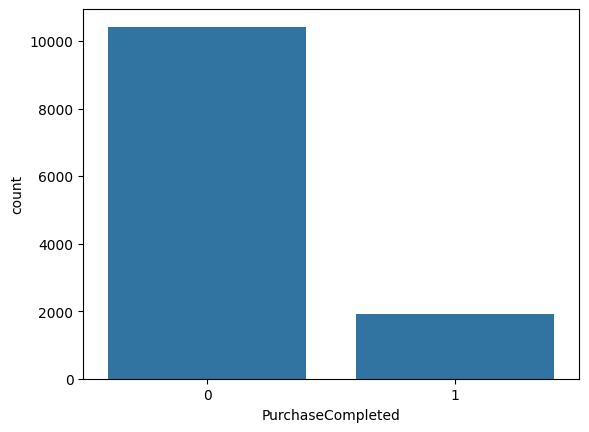

In [23]:
## Visualize the distribution of our target
sns.countplot(x='PurchaseCompleted', data=df)

In [24]:
purchase_rate = df['PurchaseCompleted'].mean()
print(purchase_rate)

0.15474452554744525


### Observation

- The overall purchase rate is approximately **15.4%**.  
- Most sessions do not result in a purchase.


### Insight

- The dataset is **imbalanced**, with significantly more non-purchasing sessions than purchasing ones.  
- This imbalance may affect model performance and should be considered during model training and evaluation (e.g. using appropriate metrics like F1-score or AUC-ROC).

## Univariate Analysis: Numerical Features

We examine the distribution of key numerical variables to understand their spread, skewness, and potential need for transformation.

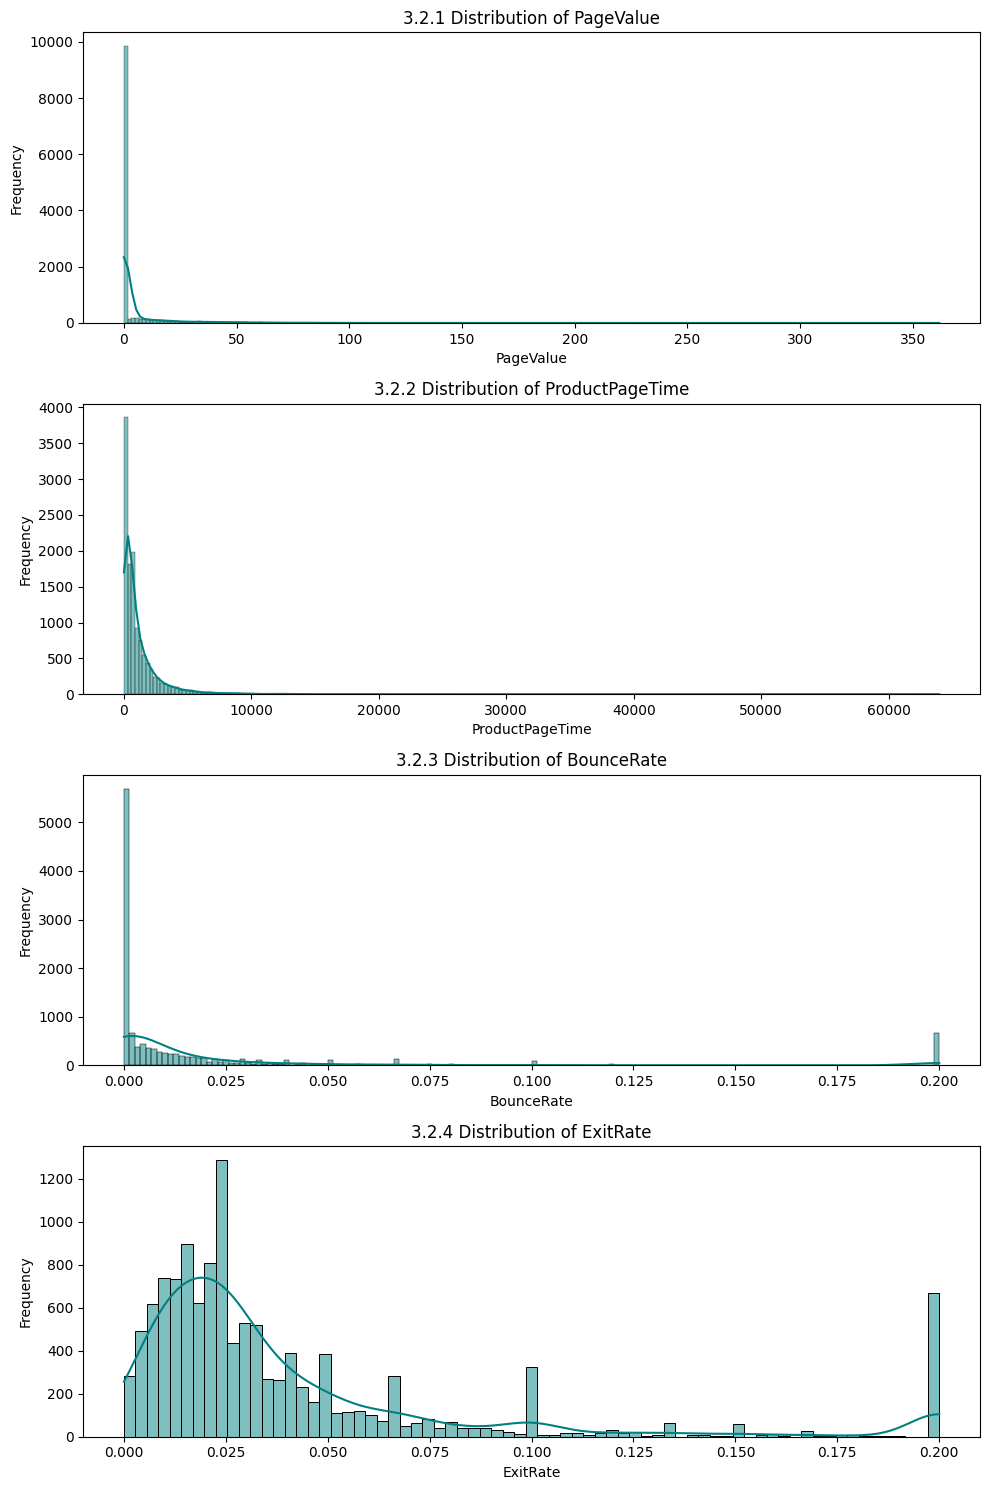

In [25]:
## List of key numerical variables
num_vars = ['PageValue', 'ProductPageTime', 'BounceRate', 'ExitRate']

## plot distribution
plt.figure(figsize=(10, 15))

for i, var in enumerate(num_vars):
    plt.subplot(len(num_vars), 1, i+1)
    sns.histplot(df[var], kde=True, color='teal')
    plt.title(f'3.2.{i+1} Distribution of {var}', fontsize=12)
    plt.xlabel(var)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Observations

- **PageValue**  
  - Strong zero inflation (majority of sessions = 0)  
  - Highly right-skewed with a few large values  

- **ProductPageTime**  
  - Long-tailed distribution  
  - Most users spend short durations, few spend significantly longer  

- **BounceRate**  
  - Heavily concentrated near 0  
  - Higher bounce rates are less frequent  

- **ExitRate**  
  - Right-skewed distribution  
  - Most sessions have low exit rates  

### Insights

- Several features (especially **PageValue** and **ProductPageTime**) exhibit strong right skewness.  
- Log transformation (e.g. `log(1 + x)`) may help stabilize variance and improve model performance.  

While univariate analysis helps us understand individual feature behavior, it does not capture relationships with the target variable.  

Next, we perform **bivariate analysis** to study how these features influence purchasing behavior.

## Univariate Analysis: Categorical Features

We examine the distribution of categorical variables to understand class balance and identify dominant categories.

<Axes: xlabel='CustomerType', ylabel='count'>

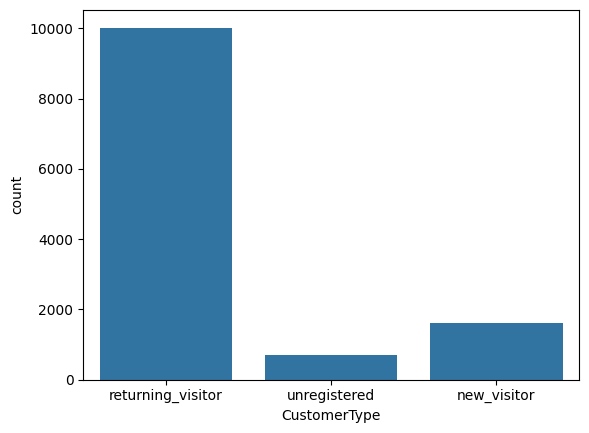

In [26]:
## plot CustomerType
sns.countplot(x='CustomerType', data=df)

<function matplotlib.pyplot.show(close=None, block=None)>

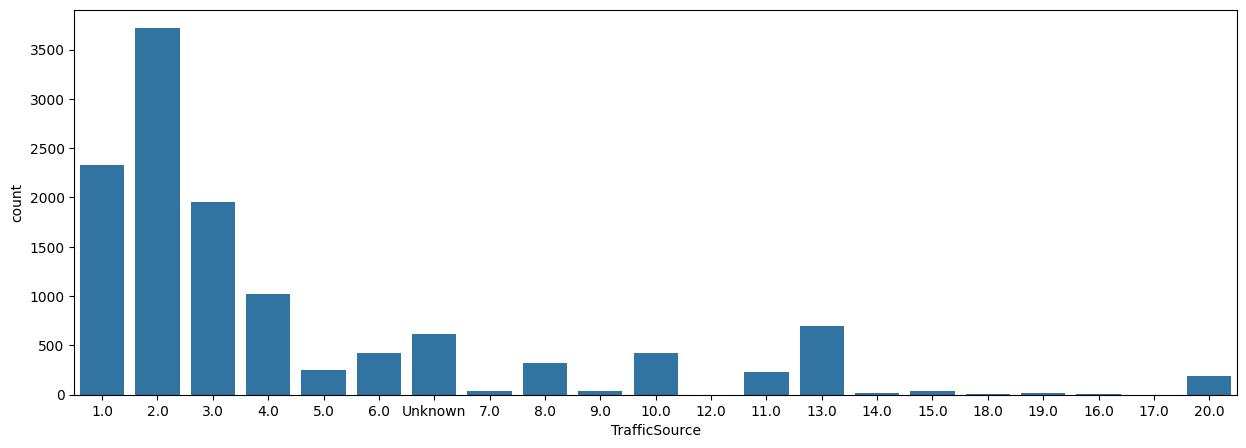

In [27]:
## plot TrafficSource 
plt.figure(figsize=(15, 5))
sns.countplot(x='TrafficSource', data=df)
plt.show

In [28]:
df['TrafficSource'].value_counts()

TrafficSource
2.0        3718
1.0        2334
3.0        1950
4.0        1017
13.0        695
Unknown     616
10.0        427
6.0         421
8.0         321
5.0         253
11.0        232
20.0        188
9.0          41
7.0          39
15.0         36
19.0         16
14.0         13
18.0          8
16.0          3
12.0          1
17.0          1
Name: count, dtype: int64

<Axes: xlabel='GeographicRegion', ylabel='count'>

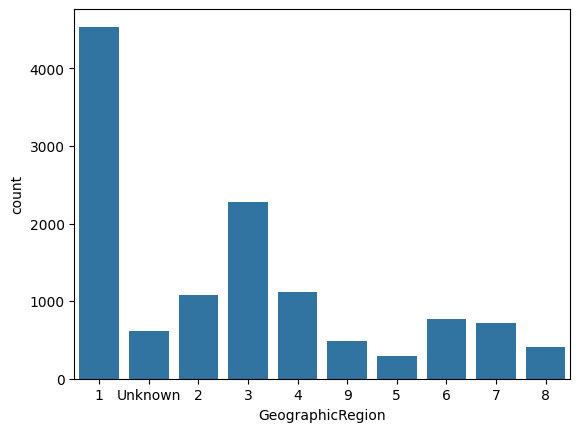

In [29]:
## Plot Geograhic Region
sns.countplot(x='GeographicRegion', data=df)

### Observations

- **CustomerType**  
  - Majority of sessions come from **returning visitors**  
  - Smaller proportion from new and unregistered users  
  - Indicates strong repeat user presence  

- **TrafficSource**  
  - Highly imbalanced distribution  
  - A few sources (e.g. 1, 2, 3) dominate the dataset  
  - Many sources have very low frequency  

- **GeographicRegion**  
  - Previously invalid values were grouped as `"Unknown"`  
  - A few regions (e.g. Region 1, Region 3) dominate user activity  

### Insights

- Categorical features are **heavily imbalanced**, with dominant categories across all variables.  
- Low-frequency categories (especially in `TrafficSource`) may introduce noise and could be grouped during feature engineering.  
- The dominance of returning users suggests potential behavioral differences worth exploring in relation to purchase outcomes.  

These patterns will be further analyzed in the next section using **bivariate analysis** to understand their impact on `PurchaseCompleted`.

## Special Day Proximity

We examine the distribution of `SpecialDayProximity`, an ordinal feature indicating how close a session is to a special shopping event.

<Axes: xlabel='SpecialDayProximity', ylabel='count'>

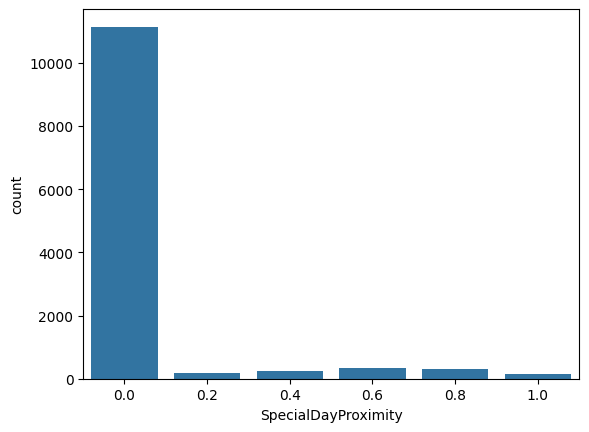

In [30]:
## plot SpecialDayProximity
sns.countplot(x='SpecialDayProximity', data=df)

### Observations

- The distribution is heavily dominated by **0**, indicating most sessions occur with no nearby special event  
- Higher proximity values have significantly fewer sessions  
- User activity is concentrated during regular (non-event) periods  

### Insights

- The feature is **highly imbalanced**, with limited variation across values  
- Although most sessions occur outside special events, sessions closer to special days may still exhibit different purchasing behavior  
- This makes `SpecialDayProximity` a potentially useful feature when analyzed against the target variable  

Next, we explore **bivariate relationships** to understand how features influence purchase outcomes.

# Bivariate Analysis

We now examine how different features influence the target variable `PurchaseCompleted`.

For categorical variables, we compare **purchase rates across categories** to identify patterns and potential predictive signals.

## Bivariate analysis for categorical variables

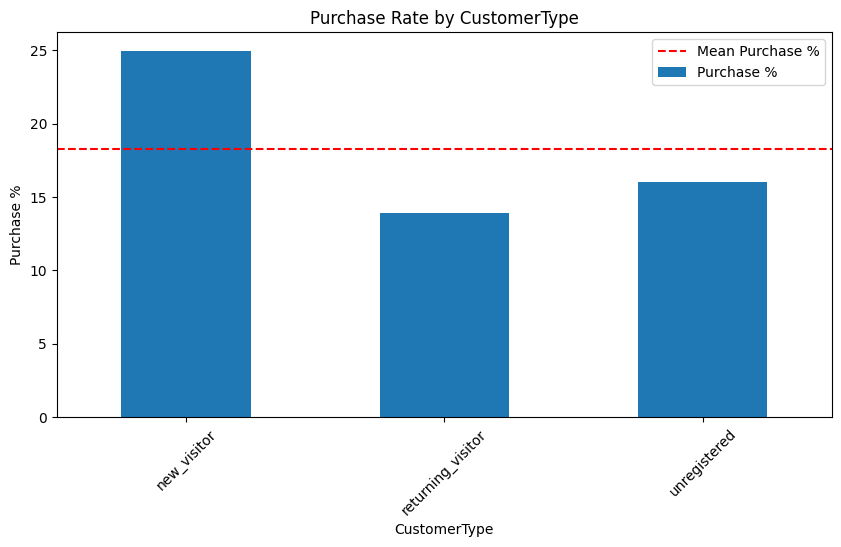

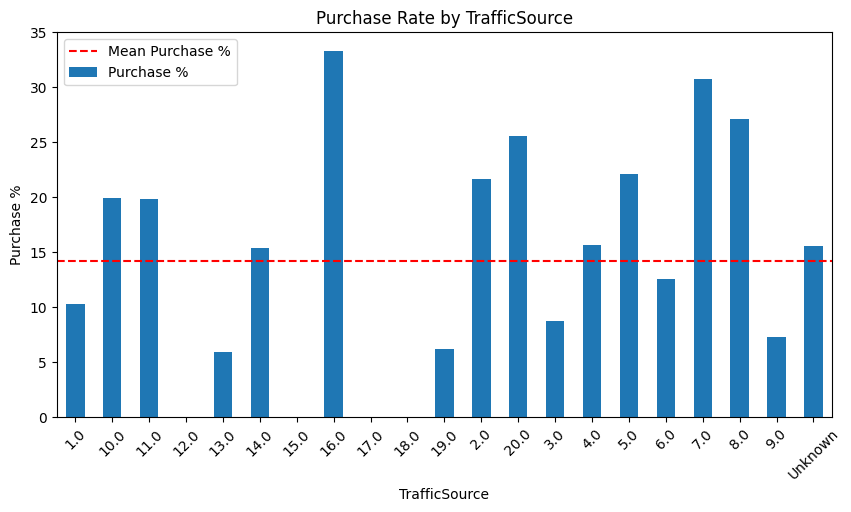

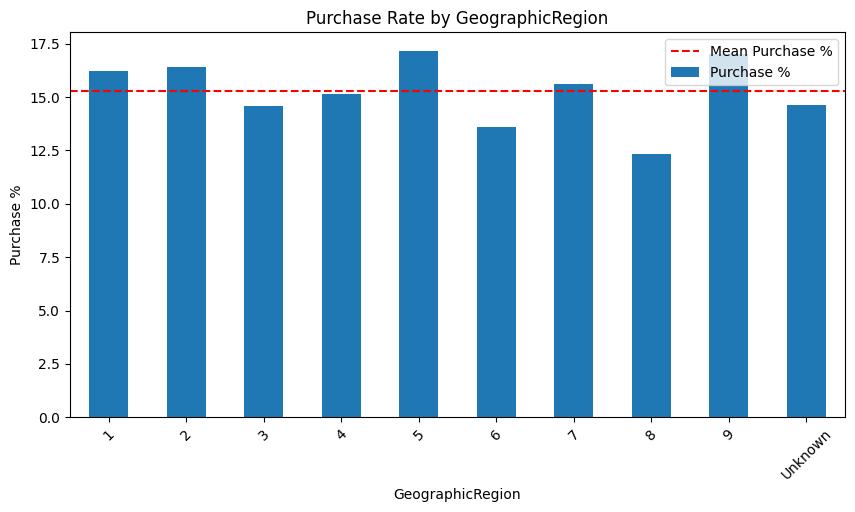

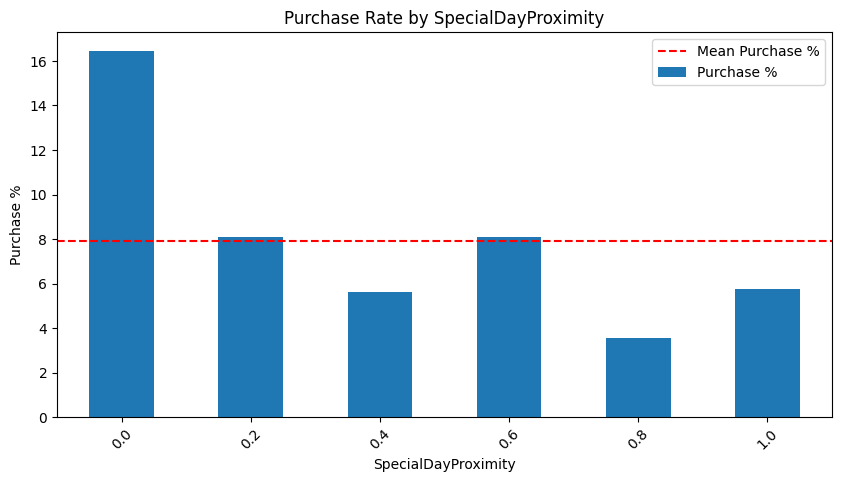

In [34]:
cat_vars = ['CustomerType', 'TrafficSource', 'GeographicRegion', 'SpecialDayProximity']
df[cat_vars] = df[cat_vars].astype(str)

for var in cat_vars:
    # Compute purchase rate
    temp = df.groupby(var)['PurchaseCompleted'] \
             .value_counts(normalize=True) \
             .unstack() \
             .fillna(0)

    temp['Purchase%'] = temp[1] * 100
    temp = temp.reset_index()

    # Plot
    ax = temp.plot(kind='bar', x=var, y='Purchase%', figsize=(10,5))
    ax.set_title(f'Purchase Rate by {var}')
    ax.set_ylabel('Purchase %')
    ax.tick_params(axis='x', rotation=45)

    # Mean line
    mean_purchase = temp['Purchase%'].mean()
    ax.axhline(y=mean_purchase, color='r', linestyle='--')
    ax.legend(['Mean Purchase %', 'Purchase %'])    
    plt.show()

### Observations

- **CustomerType**  
  - New visitors have the highest purchase rate and are the only group above the mean  
  - Returning visitors show the lowest purchase rate  
  - Suggests first-time users may have stronger purchase intent  

- **TrafficSource**  
  - Some sources (e.g. 12, 15, 17, 18) show 0% purchase rate  
  - A few dominant sources perform above the mean  
  - Low-frequency categories should be interpreted cautiously  

- **GeographicRegion**  
  - Regions 1, 2, 5, and 9 are above average  
  - Regions 6 and 8 show lower purchase rates  
  - Variation exists, but differences are moderate  

- **SpecialDayProximity**  
  - Higher proximity values tend to show slightly different purchase behavior  
  - However, most data is concentrated at 0, limiting strong conclusions  

### Insights

- All categorical variables show **variation in purchase rates**, indicating potential predictive value  
- Features like `CustomerType` and `TrafficSource` appear more influential  
- Categories with very low counts (especially in `TrafficSource`) may produce unreliable signals  

These features should be retained for modeling, with potential grouping of sparse categories during feature engineering.

## Bivariate Analysis: Numerical Features

We analyze how numerical variables differ between purchasing and non-purchasing sessions.

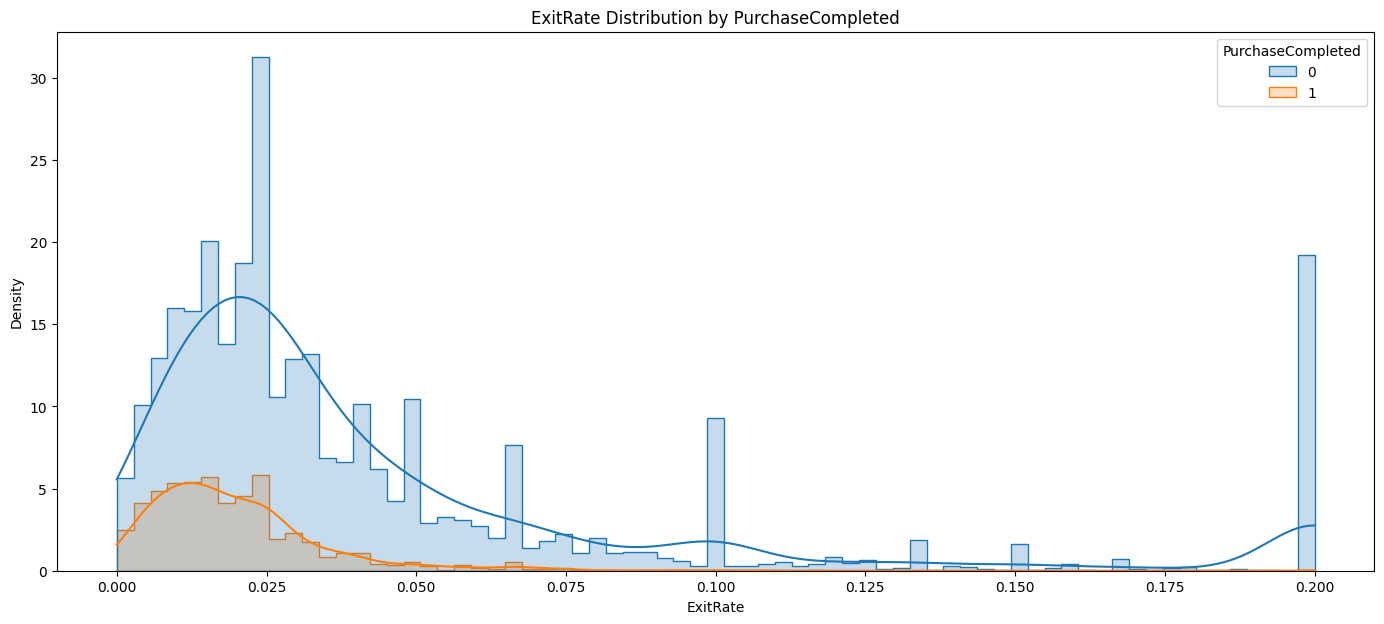

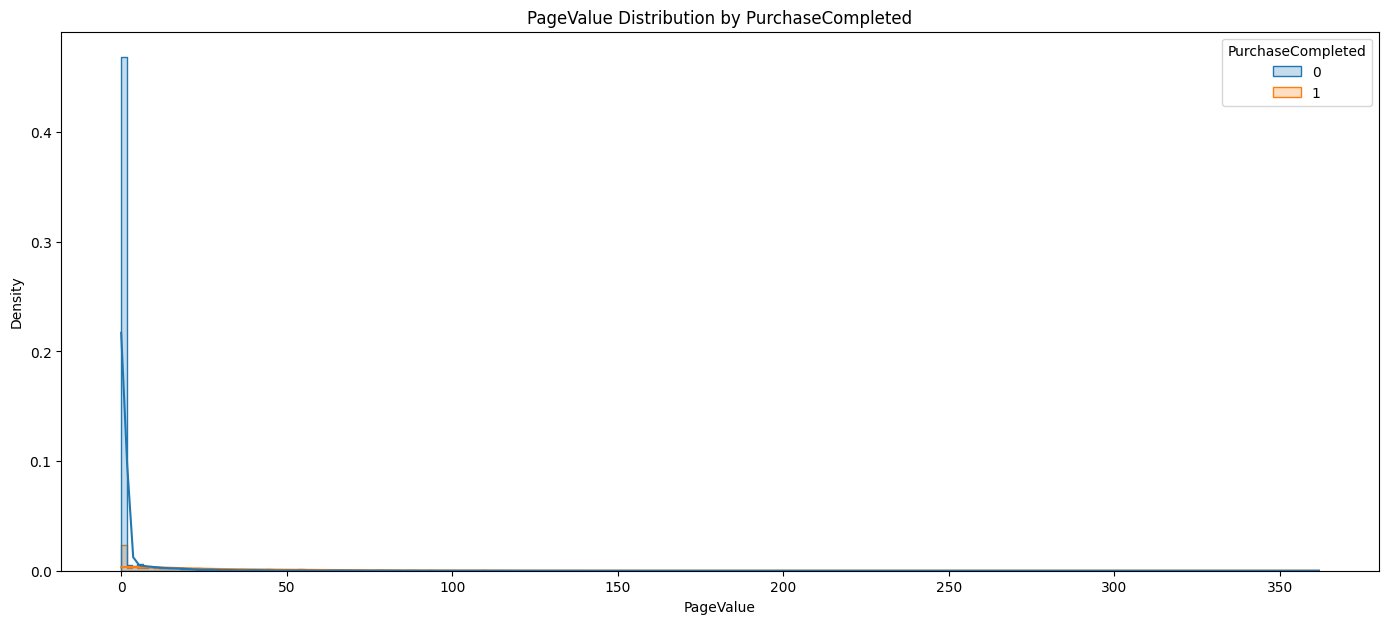

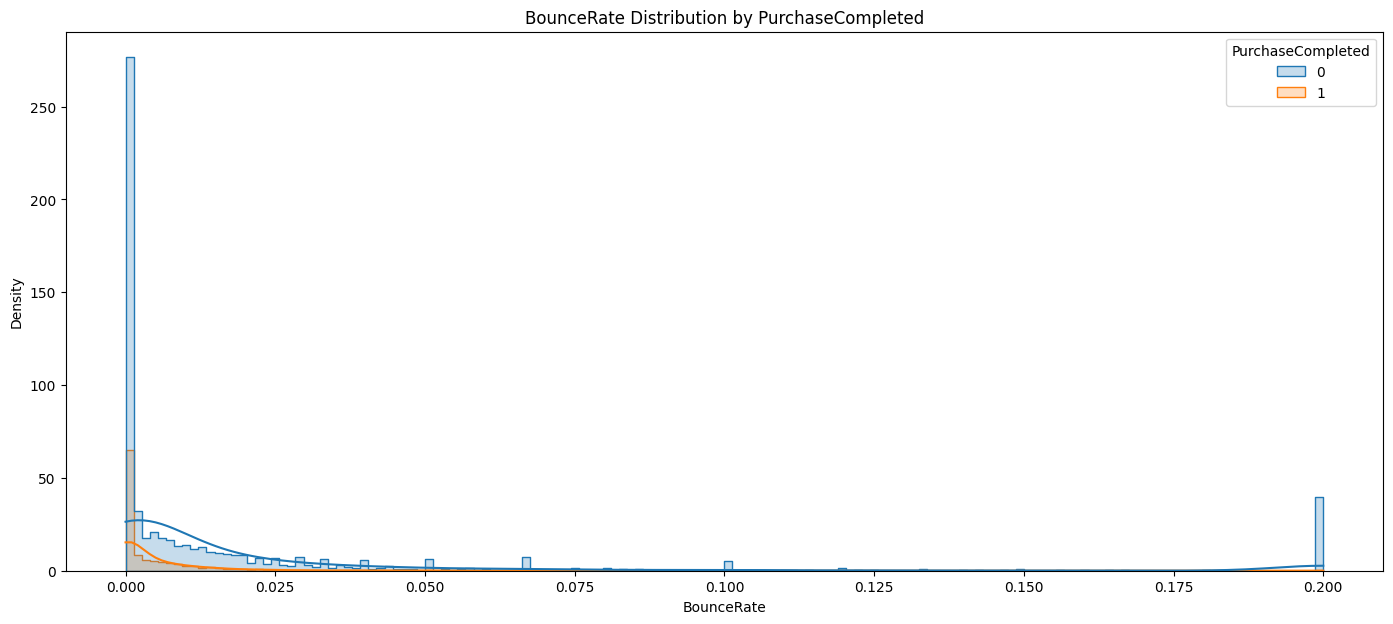

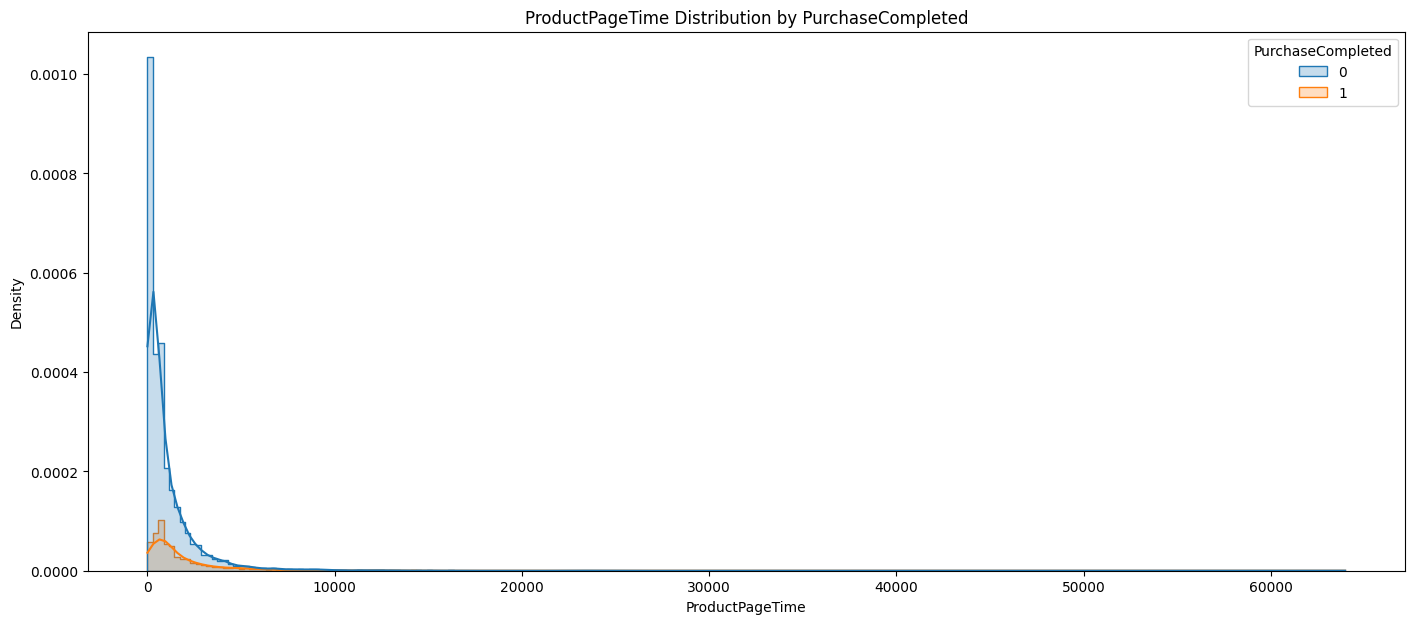

In [40]:
num_vars = ['ExitRate', 'PageValue', 'BounceRate', 'ProductPageTime']
for col in num_vars:
    plt.figure(figsize=(17,7))
    sns.histplot(df, x=col, hue='PurchaseCompleted', kde=True, element='step', stat='density')
    plt.title(f'{col} Distribution by PurchaseCompleted')
    plt.show()

In [41]:
## Find meand and median
df.groupby('PurchaseCompleted')[['BounceRate', 'PageValue', 'ExitRate', 'ProductPageTime']].agg(['mean', 'median']).round(3)

BounceRate        PageValue         ExitRate         \
                        mean median      mean  median     mean median   
PurchaseCompleted                                                       
0                      0.024  0.003     1.867   0.000    0.046  0.027   
1                      0.005  0.000    26.062  15.371    0.020  0.017   

                  ProductPageTime            
                             mean    median  
PurchaseCompleted                            
0                        1052.089   576.845  
1                        1808.623  1011.168

### Observations

- **BounceRate**  
  - Purchasers show lower mean and median values  
  - Indicates lower early-session abandonment  

- **ExitRate**  
  - Purchasers also have consistently lower values  
  - Suggests they are less likely to leave prematurely  

- **PageValue**  
  - Strong separation between groups  
  - Purchasers have significantly higher values  
  - Many non-purchasing sessions have near-zero values  

- **ProductPageTime**  
  - Purchasers spend more time on product pages  
  - Indicates deeper engagement before conversion  

### Insights

- **PageValue** and **ProductPageTime** show strong positive association with purchase behavior  
- **BounceRate** and **ExitRate** show negative association with purchase completion  
- These features demonstrate clear separation between classes and are likely to be highly predictive  

- Differences between mean and median across variables confirm **skewed distributions**, consistent with earlier univariate analysis  

These numerical features should be retained for modeling, with potential transformation (e.g. log scaling) to handle skewness.

# Multivariate Analysis

To complement the univariate and bivariate analysis, we visualize correlations between numerical features and the target variable. This helps identify the strength and direction of linear relationships, as well as potential predictive value for purchase completion.

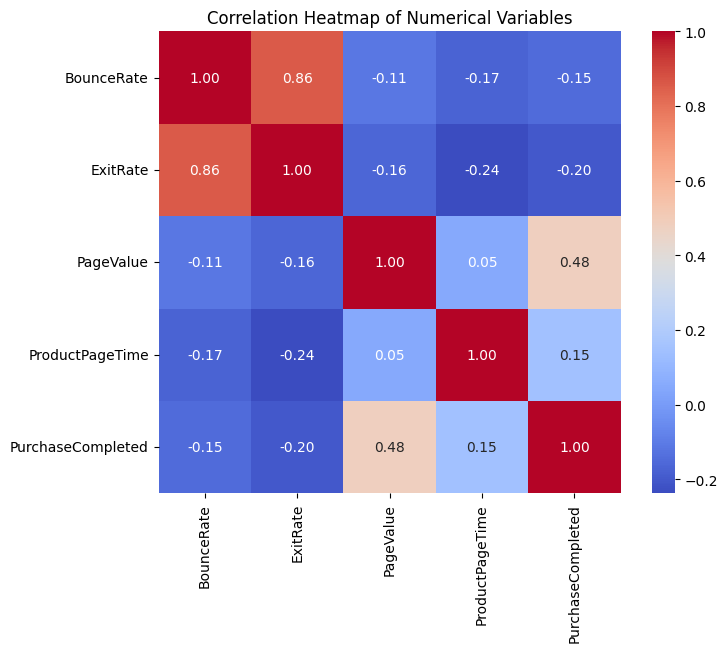

In [43]:
## plot heatmap for numerical variables
numerical_cols = ['BounceRate', 'ExitRate', 'PageValue', 'ProductPageTime', 'PurchaseCompleted']

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

In [51]:
## Since the corr for exitrate and bouncerate is quite high, lets check the VIF 

# Select numerical features only
numerical_features = ['BounceRate', 'ExitRate', 'PageValue', 'ProductPageTime']

# Create a dataframe of only numerical features
X = df[numerical_features].copy()

# Calculate VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

           Feature       VIF
0       BounceRate  3.878883
1         ExitRate  4.019983
2        PageValue  1.045029
3  ProductPageTime  1.108473


### Observations

- **PageValue** has the strongest positive correlation with `PurchaseCompleted` (~0.48), followed by **ProductPageTime** (~0.15).  
  - Sessions with higher page value and longer product page time are more likely to result in a purchase.

- **BounceRate** and **ExitRate** show weak negative correlations (~-0.20 and -0.15), indicating higher early abandonment is associated with lower likelihood of purchase.

- **BounceRate** and **ExitRate** are highly correlated (~0.86), suggesting they capture similar user behavior patterns.

- Variance Inflation Factor (VIF) for all numerical features is below 5, indicating **acceptable multicollinearity**, though BounceRate and ExitRate are moderately correlated.


### Insights

- Numerical features show meaningful relationships with purchase behavior.  
- **PageValue** and **ProductPageTime** are positively associated with purchases, while **BounceRate** and **ExitRate** are negatively associated.  
- Strong correlation between BounceRate and ExitRate should be considered if feature selection or regularization is applied during modeling.  
- Overall, all numerical features are suitable for inclusion in machine learning models, with attention to skewness and multicollinearity.

## Summary of EDA

This section summarizes the key steps and insights from the exploratory data analysis.

### Problem Overview
- **Type**: Binary Classification  
- **Target Variable**: `PurchaseCompleted`  

### Data Cleaning
- Negative values in **BounceRate** & **ProductPageTime** replaced with `NaN`  
- Missing values imputed:
  - **Numerical features**: median  
  - **Categorical features**: labeled as `Unknown`  

### Univariate Analysis
**Numerical Features**:
- **PageValue** & **ProductPageTime**: right-skewed, candidates for log transformation  
- **BounceRate** & **ExitRate**: mostly low values; strongly correlated (0.86)  

**Categorical Features**:
- **CustomerType**: New visitors have the highest purchase rate  
- **GeographicRegion**: Regions 1, 2, 5, 9 above mean purchase rate  
- **TrafficSource**: Some sources show 0 purchase rate; others split above/below mean  
- **SpecialDayProximity**: Sessions close to special days (0.0, 0.2, 0.6) slightly above mean; others below  

### Bivariate & Multivariate Insights
**Numerical Variables vs Target**:
- **PageValue** & **ProductPageTime**: higher values associated with purchase completion  
- **BounceRate** & **ExitRate**: higher values associated with non-purchasers  

**Correlation & Multicollinearity**:
- **PageValue** strongest positive correlation with `PurchaseCompleted` (~0.48)  
- **ProductPageTime** moderate correlation (~0.15)  
- **BounceRate** & **ExitRate** highly correlated (~0.86), weak negative correlation with target  
- VIF values acceptable (<5), but BounceRate & ExitRate capture similar behavior  

# 7. Next steps for ML pipeline 

**Preprocessing**:

- Convert all negative values seen in ProductPageTime and BounceRate to NaN.

- Impute missing values using median (robust to outliers).

- Impute missing categorical values:

    - TrafficSource: Group all the 616 values from imputation as unkown and these categories [7, 9, 12, 14, 15, 16, 17, 18, 19] as others. The categories themselves contribute very little to prediction and may introduce noise later. groupuing the imputed values as known allows us to know if missingness helps with model prediction. 

    - CustomerType: relabel anything that is not returning or new customers to unregistered

    - GeographicRegion: Group all negative regions as unknown

**Feature Engineering**:

- Transform skewed numerical features (PageValue, ProductPageTime) with log(1+x) to reduce variance and improve model stability. (keep 0s valid and stabilize variance) 

- Encode categorical variables using one-hot encoding (preserves category info without introducing ordinality where none exists.)


**Data Splitting & Scaling**:

- Split the dataset into training and test sets after preprocessing but before modeling to prevent data leakage. (80% train 20% test) 

- Scale numerical variables for logistic regression models. 

**Modeling Approach**:

- Using 3 models:
    - Logistic Regression (LR): Simplest model for binary classification problem.
      
    - Random Forest: Could work well as dataset contains both numerical and categorical, and model can also handle outliers seen in ProductPageTime.
 
      
    - XGboost: Boosted ensemble that can capture complex patterns and subtle interactions that might exist between session metrics and the target

**Evaluation**:

- Use ROC-AUC as the main metric (Dataset is imbalanced (purchase rate ~15%), ROC-AUC accounts for both true positive and false positive rates, giving a better measure of discriminative ability than accuracy) 

- F1-score/Precision-Recall to assess trade-offs between false positives and false negatives and also to understand minority class performance.